# Bank Customer Churn Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, auc, cohen_kappa_score
)
import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.utils.parallel')

## 1. Load & Inspect Data

In [2]:
df = pd.read_csv('Churn_Modelling.csv')
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nClass Distribution:\n", df['Exited'].value_counts())
print(f"\nChurn Rate: {df['Exited'].mean():.1%}")

Shape: (10000, 11)

Data Types:
 CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Missing Values:
 CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Class Distribution:
 Exited
0    7963
1    2037
Name: count, dtype: int64

Churn Rate: 20.4%


## 2. Exploratory Data Analysis

## 2.5 Feature Engineering (MS-Level Enhancement)

In [3]:
# Create derived features that add information without duplicating original columns.
# Removed redundant candidates from earlier iterations:
# - Is_Active duplicated IsActiveMember
# - Has_Credit_Card duplicated HasCrCard
# - Age_Squared, Salary_Per_Product, Zero_Balance, and High_Balance were highly correlated with originals
engineered_feature_names = [
    'Balance_Income_Ratio',
    'Products_Per_Tenure',
    'Balance_Product_Interaction',
    'Senior_Citizen_Age'
]

df['Balance_Income_Ratio'] = df['Balance'] / (df['EstimatedSalary'] + 1)
df['Products_Per_Tenure'] = df['NumOfProducts'] / (df['Tenure'] + 1)
df['Balance_Product_Interaction'] = df['Balance'] * df['NumOfProducts']
df['Senior_Citizen_Age'] = (df['Age'] > 60).astype(int)

print("\nComplete: Feature Engineering Complete")
print(f"Original features: 11 | New features: +{len(engineered_feature_names)} | Total: {df.shape[1]}")
print(f"\nNew features created:\n{engineered_feature_names}")


Complete: Feature Engineering Complete
Original features: 11 | New features: +4 | Total: 15

New features created:
['Balance_Income_Ratio', 'Products_Per_Tenure', 'Balance_Product_Interaction', 'Senior_Citizen_Age']


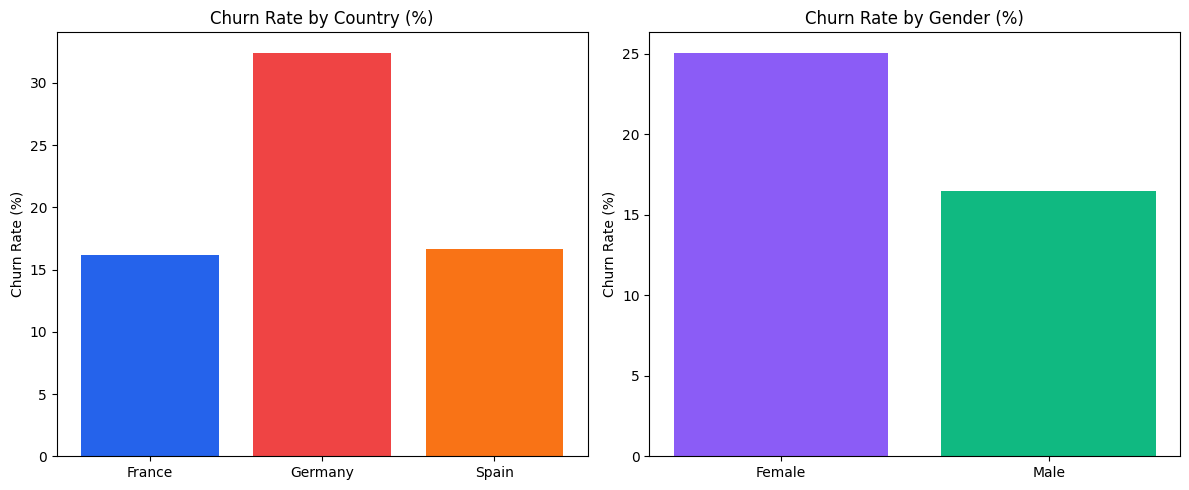

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

geo_churn = df.groupby('Geography')['Exited'].mean() * 100
axes[0].bar(geo_churn.index, geo_churn.values, color=['#2563EB', '#EF4444', '#F97316'])
axes[0].set_title('Churn Rate by Country (%)')
axes[0].set_ylabel('Churn Rate (%)')

gen_churn = df.groupby('Gender')['Exited'].mean() * 100
axes[1].bar(gen_churn.index, gen_churn.values, color=['#8B5CF6', '#10B981'])
axes[1].set_title('Churn Rate by Gender (%)')
axes[1].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('eda_categorical.png', dpi=150)
plt.show()

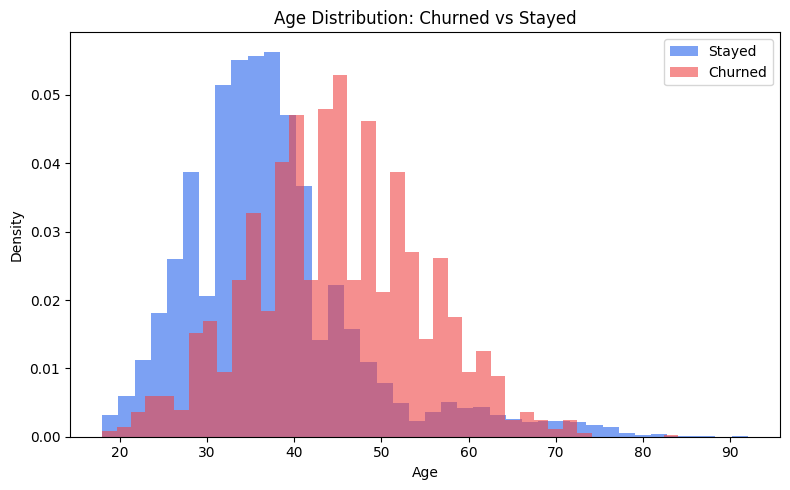

In [5]:
stayed  = df[df['Exited'] == 0]
churned = df[df['Exited'] == 1]

plt.figure(figsize=(8, 5))
plt.hist(stayed['Age'],  bins=40, alpha=0.6, color='#2563EB', label='Stayed',  density=True)
plt.hist(churned['Age'], bins=40, alpha=0.6, color='#EF4444', label='Churned', density=True)
plt.title('Age Distribution: Churned vs Stayed')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('eda_age.png', dpi=150)
plt.show()

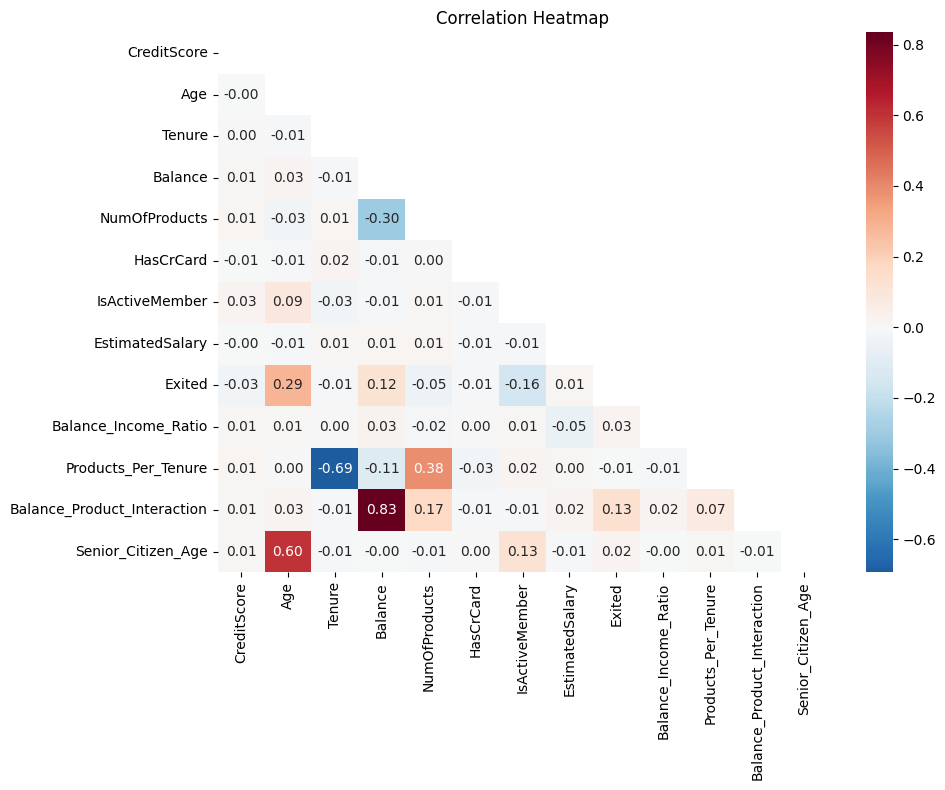

In [6]:
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include='number').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('eda_heatmap.png', dpi=150)
plt.show()

## 3. Preprocessing

In [7]:
# Proper encoding: OneHotEncoder instead of LabelEncoder
categorical_features = ['Geography', 'Gender']
numerical_features = [col for col in df.columns if col not in categorical_features + ['Exited', 'RowNumber', 'CustomerId', 'Surname']]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Complete: Preprocessing Complete (with Proper OneHotEncoding)")
print(f"Train size: {len(X_train):,} | Test size: {len(X_test):,}")
print(f"Features after encoding: {X_train_processed.shape[1]}")
print(f"Class distribution (Train):\n{y_train.value_counts()}")
print(f"Imbalance ratio: {(y_train.value_counts()[0] / y_train.value_counts()[1]):.2f}:1")

Complete: Preprocessing Complete (with Proper OneHotEncoding)
Train size: 8,000 | Test size: 2,000
Features after encoding: 15
Class distribution (Train):
Exited
0    6370
1    1630
Name: count, dtype: int64
Imbalance ratio: 3.91:1


## 4. Train Models

## 3.5 Class Imbalance Handling with SMOTE


In [8]:
# Apply SMOTE to training data only (prevent data leakage)
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print("Complete: SMOTE Applied to Training Data")
print(f"Original class distribution:\n{pd.Series(y_train).value_counts()}")
print(f"\nAfter SMOTE:\n{pd.Series(y_train_smote).value_counts()}")
print(f"Training set size increased: {len(X_train)} -> {len(X_train_smote)}")

Complete: SMOTE Applied to Training Data
Original class distribution:
Exited
0    6370
1    1630
Name: count, dtype: int64

After SMOTE:
Exited
1    6370
0    6370
Name: count, dtype: int64
Training set size increased: 8000 -> 12740


In [9]:
print("="*70)
print("BASELINE MODELS (Without Hyperparameter Tuning)")
print("="*70)

baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1),
}

baseline_results = {}
for name, model in baseline_models.items():
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]
    
    baseline_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_prob),
        'Kappa': cohen_kappa_score(y_test, y_pred),
    }
    print(f"\n{name}:\n{classification_report(y_test, y_pred, target_names=['Stayed', 'Churned'])}")

print("\n" + "="*70)
print("ADVANCED MODELS WITH HYPERPARAMETER TUNING & 5-FOLD CV")
print("="*70)

# 1. Logistic Regression with Tuning
lr_params = {'C': [0.001, 0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}
lr_grid = GridSearchCV(LogisticRegression(max_iter=500, random_state=42), lr_params, cv=5, scoring='f1', n_jobs=1)
lr_grid.fit(X_train_processed, y_train)

# 2. Random Forest with Tuning
rf_params = {'n_estimators': [100, 200], 'max_depth': [5, 10, 15], 'min_samples_split': [2, 5]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=1), rf_params, cv=5, scoring='f1', n_jobs=1)
rf_grid.fit(X_train_processed, y_train)

# 3. XGBoost with Tuning
xgb_params = {'n_estimators': [100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1]}
xgb_grid = GridSearchCV(xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=1), 
                        xgb_params, cv=5, scoring='f1', n_jobs=1)
xgb_grid.fit(X_train_processed, y_train)

# 4. LightGBM with Tuning
lgb_params = {'n_estimators': [100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1]}
lgb_grid = GridSearchCV(lgb.LGBMClassifier(random_state=42, n_jobs=1, verbose=-1), 
                        lgb_params, cv=5, scoring='f1', n_jobs=1)
lgb_grid.fit(X_train_processed, y_train)

tuned_models = {
    'Logistic Regression (Tuned)': lr_grid.best_estimator_,
    'Random Forest (Tuned)': rf_grid.best_estimator_,
    'XGBoost (Tuned)': xgb_grid.best_estimator_,
    'LightGBM (Tuned)': lgb_grid.best_estimator_,
}

tuned_results = {}
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]
    
    cv_scores = cross_val_score(model, X_train_processed, y_train, cv=5, scoring='f1')
    
    tuned_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_prob),
        'Kappa': cohen_kappa_score(y_test, y_pred),
        'CV_Mean': cv_scores.mean(),
        'CV_Std': cv_scores.std(),
        'y_pred': y_pred,
        'y_prob': y_prob,
        'model': model,
    }
    print(f"\n{name} (Best params: {model.get_params() if hasattr(model, 'get_params') else 'N/A'})")
    print(f"Cross-validation F1: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
    print(f"{classification_report(y_test, y_pred, target_names=['Stayed', 'Churned'])}")

results = {**baseline_results, **tuned_results}
print("\nComplete: All Models Trained Successfully")

BASELINE MODELS (Without Hyperparameter Tuning)

Logistic Regression:
              precision    recall  f1-score   support

      Stayed       0.84      0.96      0.90      1593
     Churned       0.67      0.29      0.40       407

    accuracy                           0.83      2000
   macro avg       0.76      0.62      0.65      2000
weighted avg       0.81      0.83      0.80      2000


Decision Tree:
              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92      1593
     Churned       0.77      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000




Random Forest:
              precision    recall  f1-score   support

      Stayed       0.88      0.97      0.92      1593
     Churned       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000


ADVANCED MODELS WITH HYPERPARAMETER TUNING & 5-FOLD CV



Logistic Regression (Tuned) (Best params: {'C': 10, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 500, 'n_jobs': None, 'penalty': 'l1', 'random_state': 42, 'solver': 'liblinear', 'tol': 0.0001, 'verbose': 0, 'warm_start': False})
Cross-validation F1: 0.408 (+/- 0.006)
              precision    recall  f1-score   support

      Stayed       0.84      0.96      0.90      1593
     Churned       0.67      0.29      0.40       407

    accuracy                           0.83      2000
   macro avg       0.76      0.62      0.65      2000
weighted avg       0.81      0.83      0.80      2000




Random Forest (Tuned) (Best params: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 15, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': 1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False})
Cross-validation F1: 0.573 (+/- 0.026)
              precision    recall  f1-score   support

      Stayed       0.88      0.97      0.92      1593
     Churned       0.81      0.46      0.58       407

    accuracy                           0.87      2000
   macro avg       0.84      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000




XGBoost (Tuned) (Best params: {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 3, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 200, 'n_jobs': 1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None, 'use_label_encoder': False})
Cross-validation F1:


LightGBM (Tuned) (Best params: {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': 5, 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 100, 'n_jobs': 1, 'num_leaves': 31, 'objective': None, 'random_state': 42, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1})
Cross-validation F1: 0.591 (+/- 0.022)
              precision    recall  f1-score   support

      Stayed       0.88      0.97      0.92      1593
     Churned       0.79      0.48      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.72      0.76      2000
weighted avg       0.86      0.87      0.86      2000


Complete: All Models Trained Successfully


## 5. Model Comparison

In [10]:
print("\n" + "="*70)
print("COMPREHENSIVE MODEL COMPARISON TABLE")
print("="*70)

comparison_data = {}
for name, res in results.items():
    comparison_data[name] = {
        'Accuracy': res.get('Accuracy', np.nan),
        'Precision': res.get('Precision', np.nan),
        'Recall': res.get('Recall', np.nan),
        'F1': res.get('F1', np.nan),
        'AUC-ROC': res.get('AUC-ROC', np.nan),
        'Kappa': res.get('Kappa', np.nan),
        'CV F1': f"{res.get('CV_Mean', np.nan):.3f}" if 'CV_Mean' in res else 'N/A',
    }

metrics_df = pd.DataFrame(comparison_data).T.round(3)
print("\n", metrics_df.to_string())

print(f"\n\n BEST MODELS:")
print(f"   By F1-Score: {metrics_df['F1'].idxmax()} ({metrics_df['F1'].max():.3f})")
print(f"   By AUC-ROC: {metrics_df['AUC-ROC'].idxmax()} ({metrics_df['AUC-ROC'].max():.3f})")
print(f"   By Recall (Find all churners): {metrics_df['Recall'].idxmax()} ({metrics_df['Recall'].max():.3f})")


COMPREHENSIVE MODEL COMPARISON TABLE

                             Accuracy Precision    Recall        F1   AUC-ROC     Kappa  CV F1
Logistic Regression            0.826   0.67052  0.285012       0.4  0.801122  0.317097    N/A
Decision Tree                 0.8595  0.773913  0.437346   0.55887  0.838856  0.482876    N/A
Random Forest                 0.8635   0.77686  0.461916  0.579353  0.851516  0.504093    N/A
Logistic Regression (Tuned)    0.826   0.67052  0.285012       0.4  0.801115  0.317097  0.408
Random Forest (Tuned)         0.8675  0.808696  0.457002  0.583987  0.858203  0.512321  0.573
XGBoost (Tuned)                0.868  0.784861  0.484029  0.598784  0.867439  0.525046  0.589
LightGBM (Tuned)              0.8685  0.792683  0.479115  0.597243  0.863471  0.524307  0.591


 BEST MODELS:
   By F1-Score: XGBoost (Tuned) (0.599)
   By AUC-ROC: XGBoost (Tuned) (0.867)
   By Recall (Find all churners): XGBoost (Tuned) (0.484)


## 6. Results & Visualizations

## 6.5 Learning Curves (Bias-Variance Analysis)

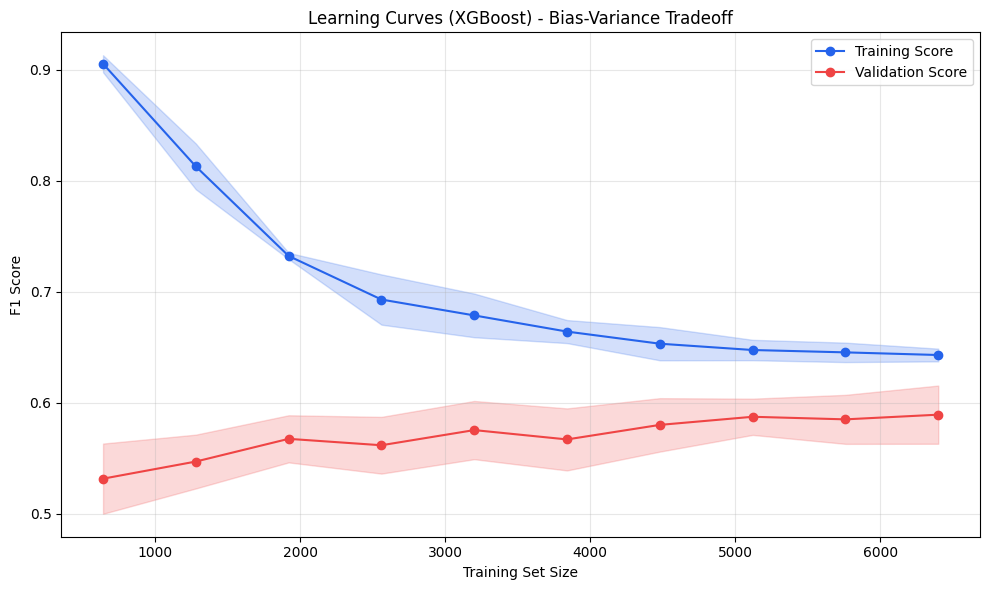

In [11]:
# Training and validation learning curves for best model
best_model = tuned_results['XGBoost (Tuned)']['model']
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_processed, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='f1', n_jobs=1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='#2563EB', label='Training Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='#2563EB')
plt.plot(train_sizes, val_mean, 'o-', color='#EF4444', label='Validation Score')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='#EF4444')
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.title('Learning Curves (XGBoost) - Bias-Variance Tradeoff')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150)
plt.show()

gap = val_mean[-1] - train_mean[-1]
if abs(gap) < 0.05:
    print("Complete: Model is well-balanced (low bias & variance)")
elif val_mean[-1] < train_mean[-1]:
    print("Warning: Possible overfitting detected (high variance)")
else:
    print("Warning: Possible underfitting detected (high bias)")

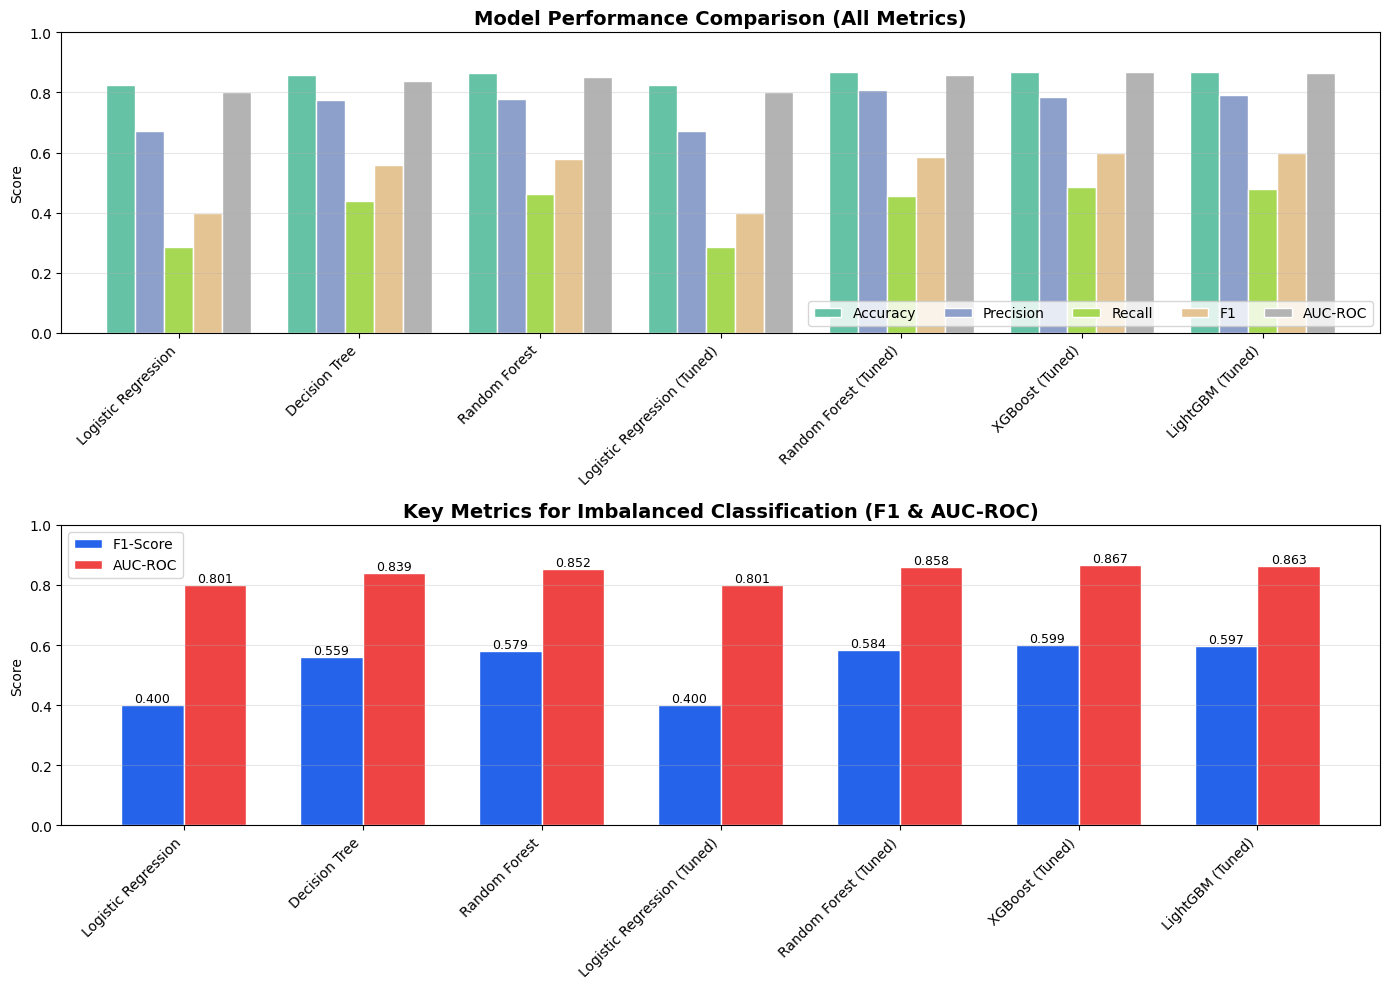

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top chart: All models performance
metrics_subset = metrics_df[['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']].copy()
metrics_subset.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white', width=0.8)
axes[0].set_title('Model Performance Comparison (All Metrics)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.0)
axes[0].legend(loc='lower right', ncol=5)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# Bottom chart: Focus on F1 and AUC-ROC (most important for imbalanced data)
key_metrics = metrics_df[['F1', 'AUC-ROC']].copy()
x = np.arange(len(key_metrics))
width = 0.35

bars1 = axes[1].bar(x - width/2, key_metrics['F1'], width, label='F1-Score', color='#2563EB', edgecolor='white')
bars2 = axes[1].bar(x + width/2, key_metrics['AUC-ROC'], width, label='AUC-ROC', color='#EF4444', edgecolor='white')

axes[1].set_title('Key Metrics for Imbalanced Classification (F1 & AUC-ROC)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1.0)
axes[1].set_xticks(x)
axes[1].set_xticklabels(key_metrics.index, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison_comprehensive.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.25 ROC Curves

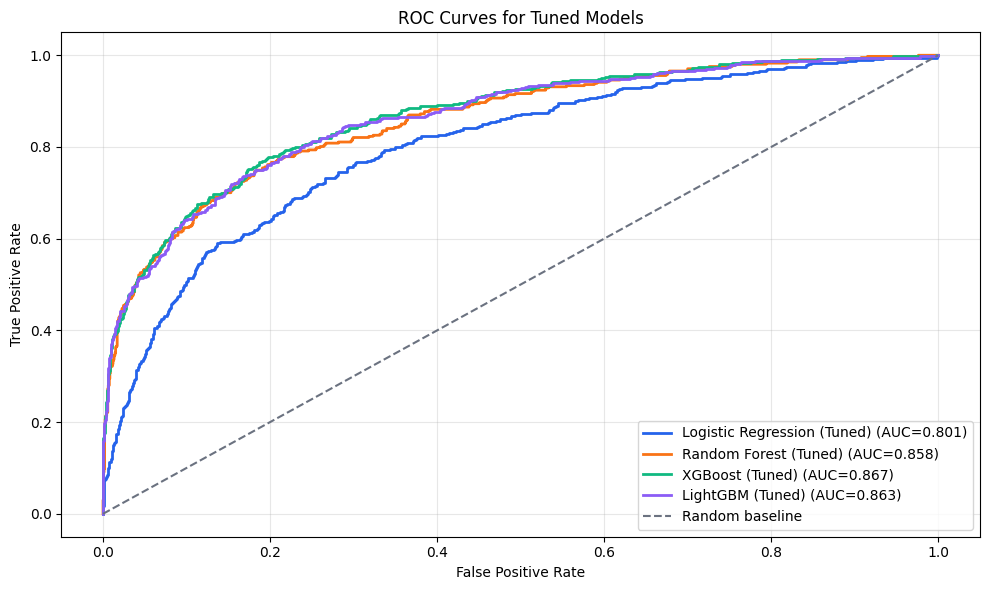

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2563EB', '#F97316', '#10B981', '#8B5CF6']

for (name, res), color in zip(tuned_results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={res['AUC-ROC']:.3f})")

ax.plot([0, 1], [0, 1], linestyle='--', color='#6B7280', label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves for Tuned Models')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()


## 6.5 Confusion Matrix and Feature Importance

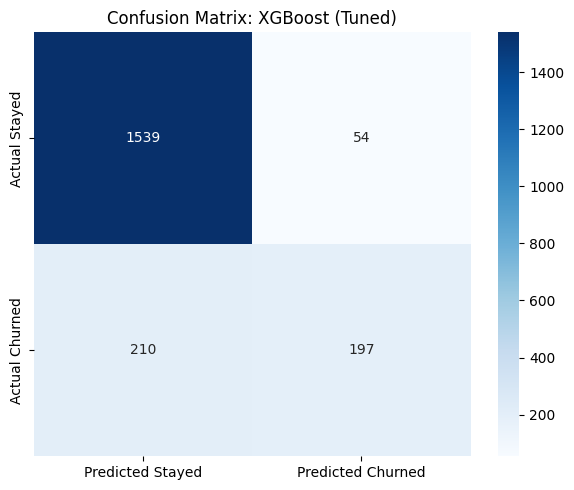

In [14]:
best_model_name = metrics_df['F1'].astype(float).idxmax()
best_predictions = results[best_model_name]['y_pred']
cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Stayed', 'Predicted Churned'],
    yticklabels=['Actual Stayed', 'Actual Churned']
)
plt.title(f'Confusion Matrix: {best_model_name}')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()


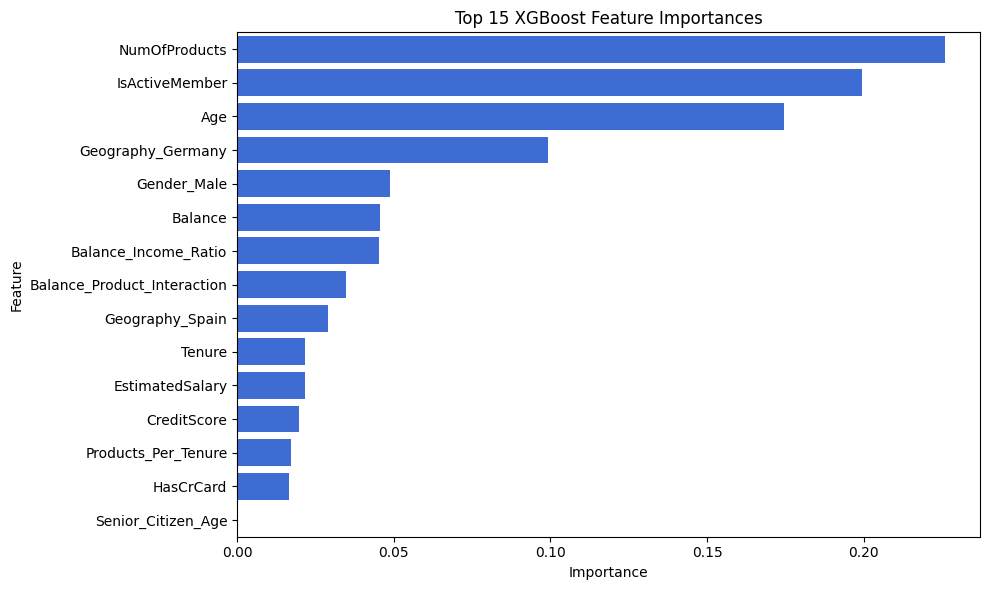

In [15]:
best_model = tuned_results['XGBoost (Tuned)']['model']
encoded_categorical = list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))
feature_names = numerical_features + encoded_categorical
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, y='Feature', x='Importance', color='#2563EB')
plt.title('Top 15 XGBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()


## 6.75 Precision-Recall Curves (Better for Imbalanced Data)

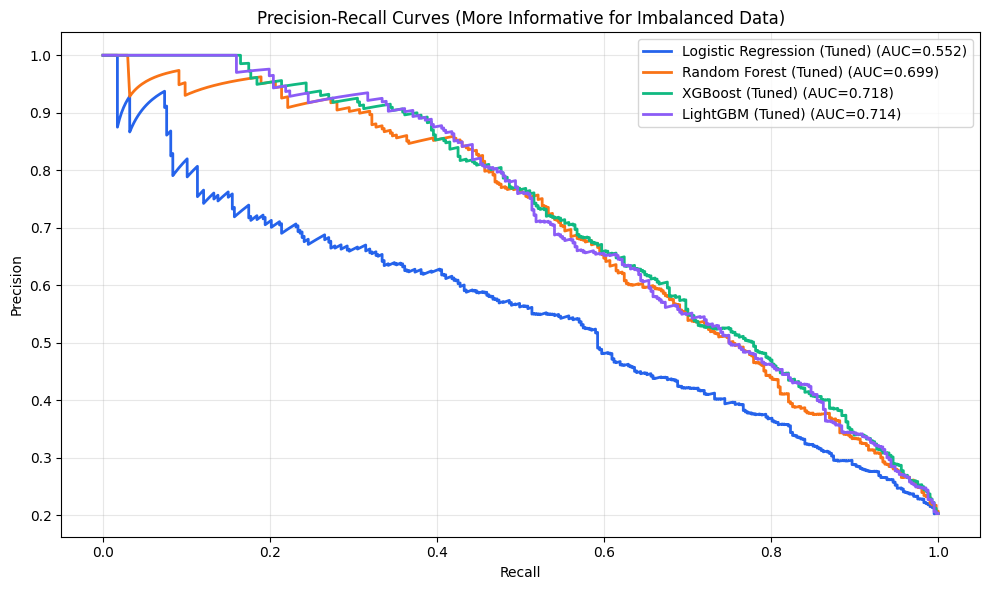

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2563EB', '#F97316', '#10B981', '#8B5CF6']

for (name, res), color in zip(list(tuned_results.items())[:4], colors):
    precision, recall, _ = precision_recall_curve(y_test, res.get('y_prob', res['y_pred']))
    pr_auc = auc(recall, precision)
    ax.plot(recall, precision, color=color, lw=2, label=f"{name} (AUC={pr_auc:.3f})")

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves (More Informative for Imbalanced Data)')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_curves.png', dpi=150)
plt.show()

## 9. Final Results and Data Findings

In [17]:
print("\n" + "="*70)
print("FINAL RESULTS AND DATA FINDINGS")
print("="*70)

metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
metrics_numeric = metrics_df[metric_cols].astype(float)

best_f1_model_name = metrics_numeric['F1'].idxmax()
best_auc_model_name = metrics_numeric['AUC-ROC'].idxmax()
best_auc_results = results[best_auc_model_name]

threshold = 0.50
y_test_array = np.asarray(y_test)
y_pred_array = np.asarray(best_auc_results['y_pred'])
y_prob_array = np.asarray(best_auc_results['y_prob'])
flagged_customers = int(np.sum(y_prob_array > threshold))
true_positives = int(np.sum((y_pred_array == 1) & (y_test_array == 1)))
false_positives = int(np.sum((y_pred_array == 1) & (y_test_array == 0)))
precision_at_threshold = true_positives / (true_positives + false_positives)

print("\nMODEL RESULTS")
print(f"   Best F1 model: {best_f1_model_name} (F1={metrics_numeric.loc[best_f1_model_name, 'F1']:.3f})")
print(f"   Best AUC-ROC model: {best_auc_model_name} (AUC-ROC={metrics_numeric.loc[best_auc_model_name, 'AUC-ROC']:.3f})")
print(f"   {best_auc_model_name} accuracy: {best_auc_results['Accuracy']:.1%}")
print(f"   {best_auc_model_name} precision: {best_auc_results['Precision']:.1%}")
print(f"   {best_auc_model_name} recall: {best_auc_results['Recall']:.1%}")
print(f"   {best_auc_model_name} F1-score: {best_auc_results['F1']:.3f}")
print(f"   {best_auc_model_name} cross-validation F1: {best_auc_results['CV_Mean']:.3f} +/- {best_auc_results['CV_Std']:.3f}")

print("\nMODEL FINDINGS AT 0.50 THRESHOLD")
print(f"   Customers flagged as likely churners: {flagged_customers}")
print(f"   Correctly identified churners: {true_positives}")
print(f"   Incorrectly flagged non-churners: {false_positives}")
print(f"   Precision among flagged customers: {precision_at_threshold:.1%}")

geo_rates = (df.groupby('Geography')['Exited'].mean() * 100).sort_values(ascending=False)
gender_rates = (df.groupby('Gender')['Exited'].mean() * 100).sort_values(ascending=False)
activity_rates = (df.groupby('IsActiveMember')['Exited'].mean() * 100).sort_values(ascending=False)
product_rates = (df.groupby('NumOfProducts')['Exited'].mean() * 100).sort_values(ascending=False)

print("\nDATA FINDINGS")
print(f"   Overall churn rate: {df['Exited'].mean():.1%} ({int(df['Exited'].sum()):,} of {len(df):,} customers)")
print(f"   Highest churn geography: {geo_rates.index[0]} ({geo_rates.iloc[0]:.1f}%)")
print(f"   Higher-churn gender segment: {gender_rates.index[0]} ({gender_rates.iloc[0]:.1f}%)")
print(f"   Average age for churned customers: {df.loc[df['Exited'] == 1, 'Age'].mean():.1f}")
print(f"   Average age for retained customers: {df.loc[df['Exited'] == 0, 'Age'].mean():.1f}")
print(f"   Inactive customer churn rate: {activity_rates.loc[0]:.1f}%")
print(f"   Active customer churn rate: {activity_rates.loc[1]:.1f}%")
print(f"   Highest churn product-count group: {product_rates.index[0]} products ({product_rates.iloc[0]:.1f}%)")

print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)


FINAL RESULTS AND DATA FINDINGS

MODEL RESULTS
   Best F1 model: XGBoost (Tuned) (F1=0.599)
   Best AUC-ROC model: XGBoost (Tuned) (AUC-ROC=0.867)
   XGBoost (Tuned) accuracy: 86.8%
   XGBoost (Tuned) precision: 78.5%
   XGBoost (Tuned) recall: 48.4%
   XGBoost (Tuned) F1-score: 0.599
   XGBoost (Tuned) cross-validation F1: 0.589 +/- 0.026

MODEL FINDINGS AT 0.50 THRESHOLD
   Customers flagged as likely churners: 251
   Correctly identified churners: 197
   Incorrectly flagged non-churners: 54
   Precision among flagged customers: 78.5%

DATA FINDINGS
   Overall churn rate: 20.4% (2,037 of 10,000 customers)
   Highest churn geography: Germany (32.4%)
   Higher-churn gender segment: Female (25.1%)
   Average age for churned customers: 44.8
   Average age for retained customers: 37.4
   Inactive customer churn rate: 26.9%
   Active customer churn rate: 14.3%
   Highest churn product-count group: 4 products (100.0%)

ANALYSIS COMPLETE
